"""  
아래 내용이 필수적으로 들어가야 합니다.

- 군집화의 개념과 기본 과정
- 거리 / 유사도 정의와 측정 방법
- 주성분 분석(PCA)의 목적
- 4가지 군집화 알고리즘의 특징과 과정
    - 계층적 군집화
    - k-means
    - DBSCAN
    - GMM
- 군집화 평가 방법 (실루엣 계수, 던 인덱스)  

"""

# **군집화**
## 배경
### [머신러닝]
머신러닝: 컴퓨터가 스스로 학습할 수 있도록 하는 알고리즘
  - 지도학습: 문제와 정답을 모두 알려주고 학습시키는 방법 (회귀, 분류)
  - 비지도학습: 답을 알려주지 않고 학습시키는 방법 (군집화, 연관 분석)
### [비지도학습]
- 특징
  - 데이터 자체에 내재된 **패턴을 스스로 파악**해서 학습(by 표현학습, 피쳐학습)
  - 정답 레이블이 없어서 모델의 작업을 정확히 정의할 수 X -> **모델 성능 정확히 측정 불가**
- 적합 케이스
  - 패턴이 알려지지 않은 경우(**새로운 패턴**)
  - **패턴이 계속해서 변하는 경우**
  - 지식 일반화
  - 예시) 고객 세그먼트 분석, 이상 거래 탐지, 자연어 처리

## 군집화란?  
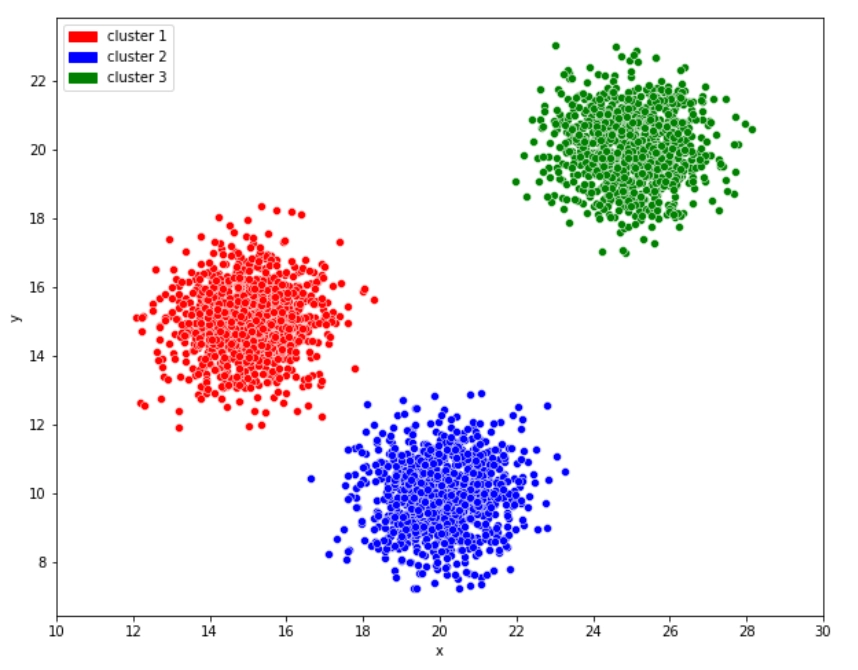  
- **데이터를 비슷한 특성을 가진 그룹(군집)으로 나누는** 비지도학습 기법 중 하나
- 종속변수를 설정하지 않고, 데이터 내부 패턴을 인식해 유사성을 기준으로 그룹화
### [군집화의 목표]
- **응집도 최대화**: 같은 군집에 속하는 데이터끼리는 최대한 비슷하게
- **분리도 최대화**: 다른 군집끼리는 최대한 구분되게
### [군집화 과정]
1. 피처 선택/추출: 군집화에 사용할 데이터의 피처 선택
2. 군집화 알고리즘 선택: 데이터의 특성과 목표에 따라 적절한 알고리즘 선택
3. 군집 유효성 검증: 군집화 수준 평가
4. 결과 해석: 각 군집이 지닌 특징 분석

# **군집화를 위한 데이터 준비**
## 군집화의 주요 고려사항
- **변수 유형 이해**: 사용할 피처의 종류와 특성에 대한 이해(연속형/명목형 구분. 변수 개수에 따라 알고리즘 달라짐)
- **거리/유사도 정의와 측정**: 군집화는 거리 또는 유사도를 기반으로 그룹을 형성하므로 거리 측정 방법이 중요 (변수 유형에 따라 적합한 거리 측정 방식 존재)
- **차원 축소**: 변수가 많아질수록 모델이 복잡해지므로 유사한 변수들을 묶거나 불필요한 변수를 삭제해서 모델 성능을 향상
## 변수 유형 이해
| 변수 유형 | 특징 | 거리 측정 | 적합한 알고리즘 | 처리 방법 / 주의사항 |
|----------|------|----------|----------------|---------------------|
| 연속형 변수 (Continuous) | 키, 몸무게, 나이, 소득 등 수치로 측정 가능 | **유클리디안 거리, 맨하탄 거리** | **K-means, 계층적 군집화** | **스케일링 필수** (단위 차이 영향 큼) |
| 명목형 변수 (Categorical) | 성별, 지역, 직업 등 범주로 구분 가능 | **해밍 거리, 자카드 거리** | **K-modes, 계층적 군집화** | 원-핫 인코딩 또는 더미 변수 변환 |
| 혼합형 변수 (Mixed) | 연속형 + 명목형이 함께 존재 | **Gower distance 등 혼합 거리** | K-prototypes, 계층적 군집화 | 변수 유형별 거리 함수 결합 |  
## 거리/유사도 정의와 측정
### [데이터의 거리 측정 방법]
군집화에서 데이터 포인트나 군집 간의 **유사성/비유사성을 수치로 계산**하는 방법  
- 유클리디안 거리 $$ d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2} $$
    - 가장 일반적
    - 직선 거리
    - K-means에서 사용
- 맨허튼 거리 $$ d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^n |x_i - y_i| $
    - 각 차원의 차이의 절댓값의 합 (계단식)
    - 이상치에 덜 민감
    > 왜 이상치에 민감하지 않을까?  

    맨허튼 거리는 절댓값의 합 -> 유클리디안 거리처럼 제곱을 하지 않아서 이상치가 과도하게 커지지 않는다

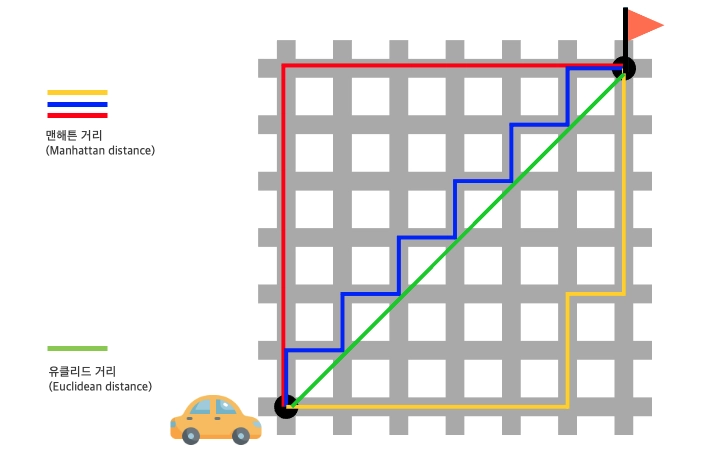  

---

- 코사인 유사도 $$ \text{similarity} = \frac{\mathbf{x} \cdot \mathbf{y}}{||\mathbf{x}|| \times ||\mathbf{y}||} $$
    - 벡터 간의 각도
    - 텍스트 데이터나 고차원 데이터에 효과적
### [6가지 연결 방법]
**계층적 군집화**에서 **두 군집 간의 거리를 계산**하는 방식  
> 계층적 군집화란?  

데이터를 점점 큰 그룹으로 묶어가는 과정. 가장 유사한 군집끼리 계속 합쳐서 하나의 큰 군집까지 도달함으로써 패턴을 찾는다.   

- **single linkage(단일 연결법/최단 연결법)** $$ \text{군집 간 거리} = \text{군집 A와 B 사이의 가장 가까운 두 점 간 거리} $$
    - **고립된 군집**을 찾는 게 목표
    - 이상치에 취약
    > 왜 이상치에 취약할까?  

    이상치가 한 클러스터에 속하면 가까이 있는 다른 클러스터와의 거리가 가까움 -> 잘못된 클러스터링 유발 가능

- **complete linkage(완전 연결법/최장 연결법)** $$ \text{군집 간 거리} = \text{군집 A와 B 사이의 가장 먼 두 점 간 거리} $$
    - **가장 유사성이 큰 군집으로 병합**해 나가는 방법
    - 군집들의 **내부 응집성**에 중점
    - 이상치에 민감
    > 가장 유사성이 큰 군집..?  

    유사성은 거리와 반비례 -> 최대 거리를 계산해서 그 중 가장 작은 거리를 가진(= 유사성이 가장 큰) 두 군집을 합침  
    => 계층적 군집화에서 두 그룹을 합칠 떄, 그 안의 모든 점들이 서로 너무 멀지 않게 하기 위해서 

- **average linkage(평균 연결법)** $$ \text{군집 간 거리} = \text{군집 A와 B의 모든 점 쌍 사이 거리의 평균} $$
    - **모든 항목에 대한 거리 평균 계산** -> 계산량이 불필요하게 많아질 수 O
    - 위 두 개보다 이상치에 덜 민감
- **centroid method(중심 연결법)** $$ \text{군집 간 거리} = \text{각 군집의 중심점 간의 거리} $$
    - **두 군집의 중심 간의 거리** 측정 -> 시간 오래 걸림
    - 두 군집이 결합 시 새로운 군집의 평균 -> **가중평균**
    - 덴드로그램에서 거리 축이 위에서 아래로 줄어드는 inversion 발생 가능
    > 가중평균으로 구한다고?

    두 군집의 데이터 개수가 다르니까, 데이터 개수에 비례하게 영향력을 부여하기 위해서 이렇게 계산하는 게 합리적 -> 큰 군집이 중심을 더 많이 끌어당기게  

    ex) A 중심: 0, 데이터 100개 / B 중심: 10, 데이터 2개  
        일반적인 평균 -> (0 + 10) / 2 = 5 : 왜곡 심함  
        가중평균 -> (100 × 0 + 2 × 10) / 102 ≈ 0.196 -> A쪽에 중심 가까움  
    
    > 덴드로그램, inversion?  

    덴드로그램에서 거리축은 일반적으로 아래에서 위로 갈수록 더 먼, 즉 덜 유사한 군집이 합쳐지는데, inversion이 발생할 경우 나중에 합쳐진 군집의 거리가 이전에 합쳐진 거리보다 더 작아진다. 두 군집을 합칠 때 중심이 이동하면서 다른 군집과의 거리가 줄어든 것!

- **median(중앙 연결법)** $$ \text{군집 간 거리} = \text{두 군집의 중앙값 사이의 거리} $$
    - 합쳐지는 두 군집의 중심점 사이의 산술적 중간 지점을 새로운 대표값으로 설정해 거리 측정
    - 중앙값에 기반하기 때문에 극단값에 영향 덜 받음
    > 중심 연결법 vs 중앙 연결법  

    | **구분** | **중심 연결법 (Centroid)** | **중앙 연결법 (Median)** |
    | --- | --- | --- |
    | **기준점 업데이트** | 군집 내 **모든 점**의 평균 | 두 군집 **중심점 간**의 중점 |
    | **가중치** | 데이터 개수에 비례 | 군집별로 동일하게 부여 |
    | **시각적 결과** | 큰 군집 쪽으로 중심이 이동 | 두 군집의 정중앙에 중심이 위치 |  

- **Ward's Procedure(Ward 연결법)**
    - 군집 내 제곱합이 증가하지 않도록 병합
    - 군집 병합 후 군집 내 SSE(오차제곱합)의 증가분이 최소인 것을 선택
    - 보통 두 군집이 합해지면 병합된 군집의 SSE는 병합 이전 각 군집의 SSE의 합보다 커지게 되는데, 그 증가량이 가장 작아지는 방향으로 군집을 형성해 나가는 방법  
    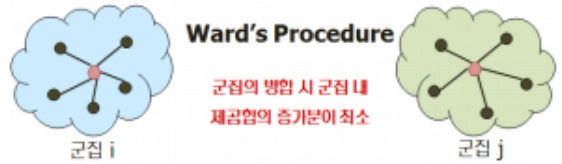  

## 차원 축소
### [왜 필요할까?]
**차원의 저주**: 피처 공간이 너무 커서 알고리즘이 데이터를 효과적/효율적으로 훈련할 수 없는 현상 -> 군집화 알고리즘이 데이터의 패턴을 정확히 인식하기 어려움
### [목표와 종류]
- 목표: 변수 제거를 통해 차원을 낮춰, **고차원 데이터를 저차원 공간에 투영하면서도 핵심 정보는 가능한 지키는 것** -> 노이즈 감소
- 종류
    - 선형 투영: 고차원 -> 저차원 선형 투영 (PCA, 특이값 분해(SVD), 랜덤 투영)
    - 매니폴드 학습(비선형 차원 축소): 유클리드 거리가 아닌 데이터 포인트들 사이의 곡선 거리를 고려하며 학습 (t-SNE, UMAP, Isomap)
### [PCA]
- 목적: 다차원 데이터에서 **가장 정보량(분산)이 큰 방향**을 찾고(->분산 최대한 보존), 그 방향을 기준으로 데이터를 투영하여(->상관관계 감소) 차원을 줄이는 것
- **주성분: 차원을 줄여서 새로 파생된 성분**  
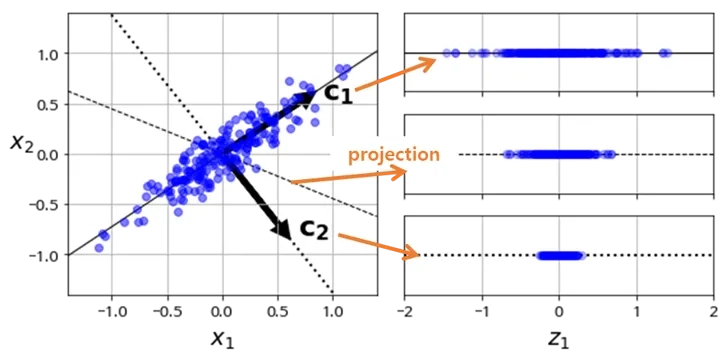  
- 과정
    1. 공분산 행렬 계산: 각 피처 쌍들의 상관성 측정
    2. 고유값 분해: 고유벡터 = 주성분의 방향, 고유값 = 각 축의 분산
    3. 고유값이 높은 상위 k개의 고유벡터 선택
    4. 데이터 투영
- 주의사항: PCA 전 반드시 데이터 표준화 수행, 결측값 처리 필수

# **군집화 알고리즘**
## 계층적 군집화
- 정의: 데이터 간의 유사성을 기반으로 트리 구조(dendrogram)를 형성하며, 상향식 또는 하향식 방식으로 군집을 형성해 나가는 방법
    > 덴드로그램이란?  

    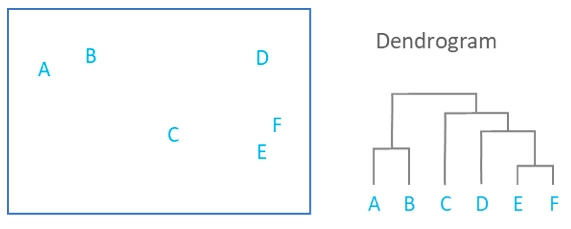  
    가까운 두 개체 또는 군집을 점차적으로 병합해가는 과정을 시각적으로 표현한 트리 구조로,  Dendrogram의 수직축(높이) = 두 군집이 병합될 때의 군집 간 거리(유사성)  

- 특징
    - 덴드로그램 생성
    - 군집화 개수를 사전에 설정 X. 클러스터링 종료 후 원하는 군집 개수 선택
    - 트리 구조에 따라 응집형과 분리형으로 구분
        - 상향식: 응집형 계층적 군집화 (병합 클러스터링)
        - 하향식: 분리형 계층적 군집화 (분할 클러스터링)
### [응집형/분리형 계층적 군집화]
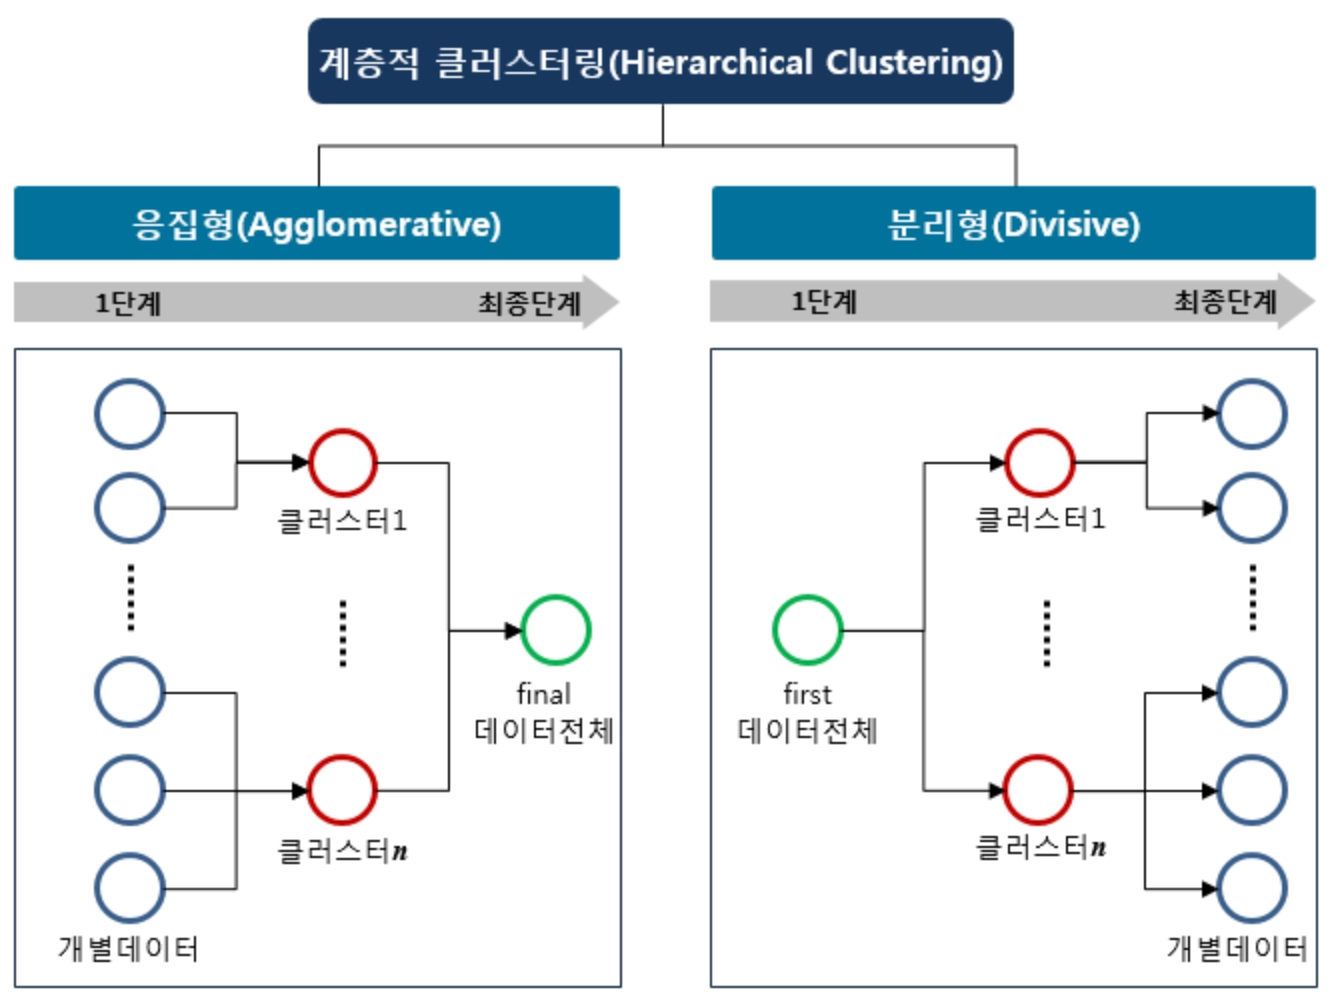  
- 응집형 클러스터링: 각 샘플을 독립적인 클러스터로 두고, 하나의 클러스터만 남을 때까지 **가장 가까운 클러스터를 병합**
    - 단일 연결, 완전 연결 방식이 대표적
    - 완전 연결을 사용한 응집형 군집화 과정
        1. **거리 행렬 계산**: 모든 데이터 포인트 간의 거리를 계산하여 거리 행렬 셍성
        2. **단일 클러스터 시작**: 각 데이터 포인트를 개별적인 클러스터로 초기화
        3. **가장 가까운 클러스터 병합**: 정의된 기준(가장 멀리 있는 샘플 간의 거리)에 따라 가장 가까운 두 클러스터를 병합하여 새로운 클러스터 생성
        4. **거리 행렬 업데이트**: 새로 생성된 클러스터와 나머지 클러스터들 간의 거리를 다시 계산하여 거리 행렬을 업데이트
        5. **반복**: 모든 데이터 포인트가 하나의 클러스터에 속할 때까지 3, 4번 과정 반복
- 분할형 클러스터링:  전체 샘플을 포함하는 하나의 클러스터에서 시작해 **유사성이 낮은 데이터들을 더 작은 클러스터로 나눔**
- 군집화 결과는 이진 트리 또는 덴드로그램으로 표현. 시각화는 다음과 같다.
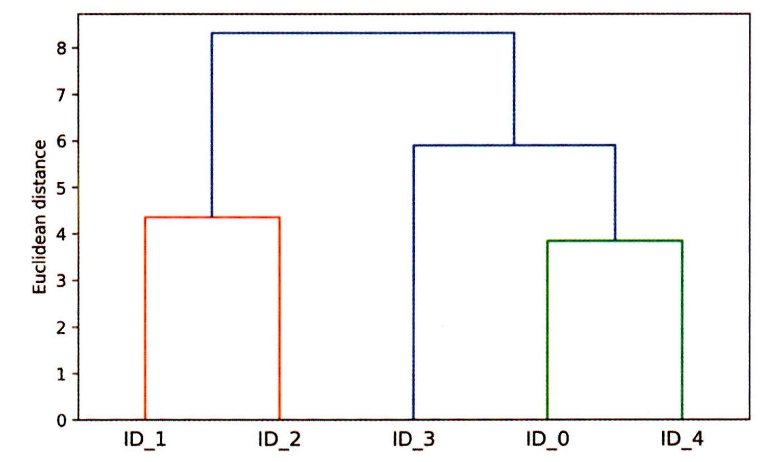  

## k-means
- 정의: 연속적인 특성을 갖는 **데이터 샘플들을 정해진 개수(K)의 그룹으로 나누되, 각 그룹의 중심점과의 거리가 가장 가까운 데이터끼리 묶는 방법**
- 프로토타입 기반 군집화: 각 클러스터의 중심을 대표점(프로토타입)으로 삼아 데이터를 묶는 방식
    - 연속형 데이터: 센트로이드(평균) 사용
    - 범주형 데이터: 메도이드(자주 등장하는 값) 사용
- **특성이 같은 스케일로 측정되었는지 확인하기** (안돼있으면 정규화 필요)
### [주요 단계]
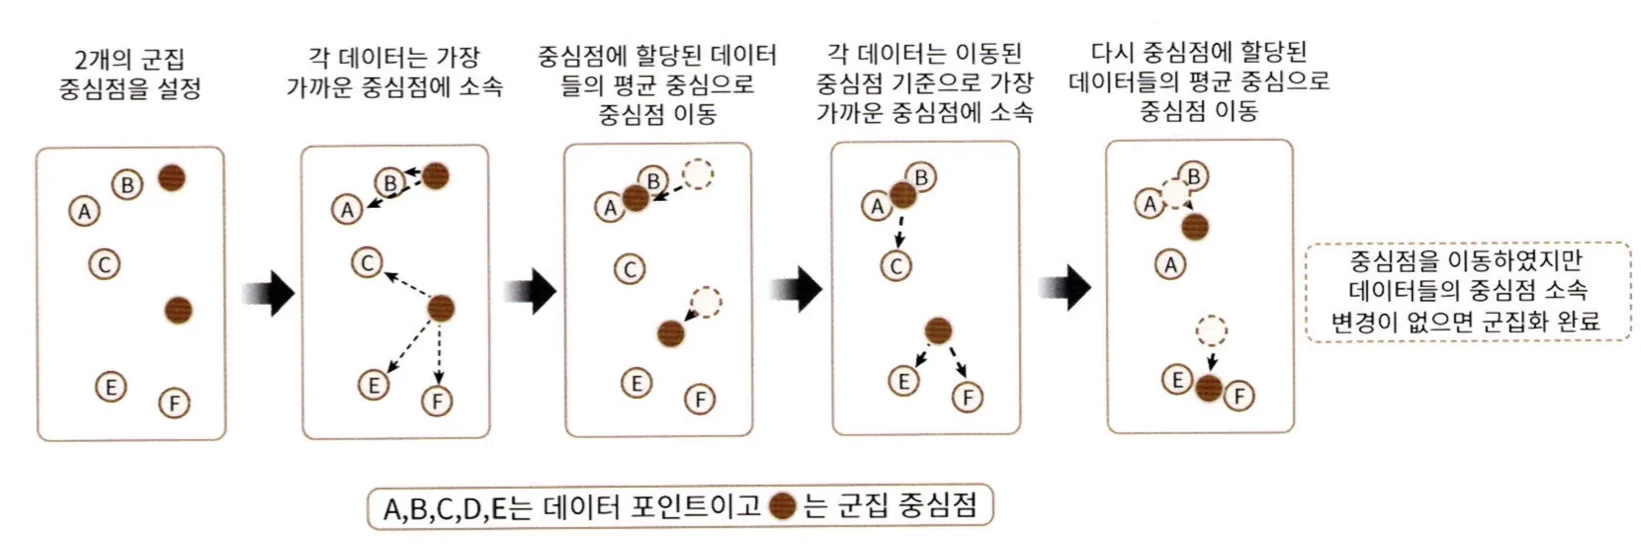  
1. 데이터 표본들 중 랜덤하게 k개의 중심점을 초기 클러스터 중심으로 선택
2. 각 표본들을 가장 가까운 중심점 $\mu^{(j)}, j \in \{ 1, …, k \}$에 할당. 이때 거리 측정은 유클리디안 거리의 제곱 사용
3. 각 클러스터에 할당된 표본들의 데이터 평균을 계산하여 중심점을 이동
4. 클러스터 할당이 변하지 않거나 사용자가 지정한 허용 오차 또는 최대 반복 횟수에 도달할 때까지 2, 3번 반복
### [장단점]
- 장점
    - 직관적이고 구현 쉬움
    - 대용량 데이터 적용 가능
- 단점
    - 초기 중심점 값에 따라 최종 군집화의 품질이 달라지거나 알고리즘 성능 하락 가능
    - 군집 수 결정 어려움 -> **엘보우 방법, 실루엣 계수** 사용
    - 평균 중심으로 군집을 구성하기 때문에 아웃라이어 하나가 중심 왜곡 가능
    > 엘보우 방법이란?

    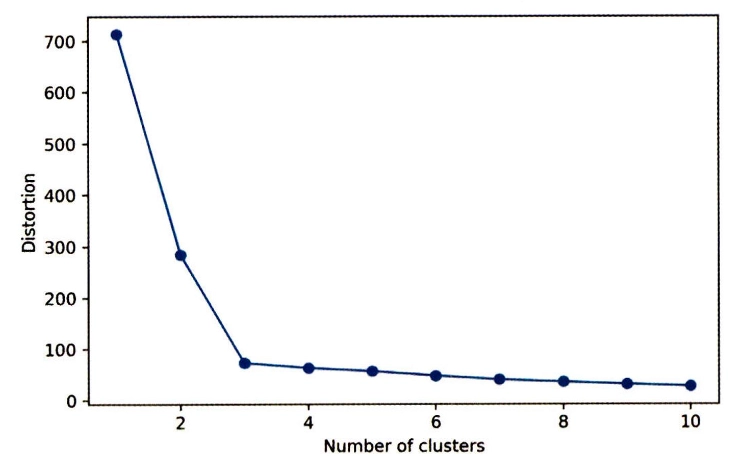  
    클래스 내 SSE를 바탕으로 그래프의 기울기가 급격히 변하는 지점의 k값을 최적의 클러스터 개수로 추정하는 방법
    - 장점: 직관적, 구현이 간단
    - 단점: 주관적 판단, 데이터에 따라 모호한 경우 존재

### [k-means++ 알고리즘]
k-means에서 **초기 중심점들을 서로 멀리 떨어진 곳에 위치**시켜 더 일관되고 좋은 결과를 도출하는 개선된 초기화 방법 -> 일관되고 좋은 결과 도출 가능
- **초기화 과정**
    1. 선택한 k개의 중심점을 저장할 빈 집합 M 초기화
    2. 입력 샘플에서 첫 번째 중심점 $\mathbf{\mu}^{(i)}$을 랜덤하게 선택하고 M에 할당
    3. M에 없는 각 샘플 $\mathbf{x}^{(i)}$에 대해 M에 있는 중심점까지의 최소 제곱 거리 $d(\mathbf{x}^{(i)}, \mathbf{M})^2$ 계산
    4. 다음 식과 같은 가중치가 적용된 확률 분포를 사용해 다음 중심점 $\mathbf{\mu}^{(p)}$을 랜덤하게 선택
    $$ \frac{d(\mathbf{\mu}^{(p)}, \mathbf{M})^2}{\sum_i d(\mathbf{x}^{(i)}, \mathbf{M})^2} $$
    5. k개의 중심점을 선택할 때까지 3, 4번 반복
    6. 기본 k-means 알고리즘을 수행

## DBSCAN
- 정의: **밀도**(=특정 거리 내에 존재해야하는 데이터 포인트의 최소 개수)**가 높은 지역의 데이터를 하나의 군집으로 묶고**, 밀도 기준을 만족하지 못하는 점은 군집에 포함시키지 않는 군집화 알고리즘
- 명시적으로 이상치 지정, 클러스터링에서 제외
- 다른 알고리즘 대비 이상치로부터 자유로움
- 어떤 데이터가 여러 군집의 특정 거리 내에 있으면 가장 밀도가 높은 군집과 그룹화
- 두 포인트가 이웃이 되기 위한 최대 거리(eps), 한 포인트가 군집이 되기 위한 eps 거리 내 최소 포인트 개수(min_samples) 직접 지정
### [주요 단계]
1. **샘플 분류**: 각 샘플을 다음 조건에 따라 분류
    - 핵심 샘플 (Core Point): 특정 반경 ε 안에 있는 이웃 샘플이 지정된 개수(MinPts) 이상인 경우
    - 경계 샘플 (Border Point): ε 이내에 MinPts보다 이웃이 적지만 다른 핵심 샘플의 반경 ε 안에 있는 경우
    - 잡음 샘플 (Noise Point): 위 두 조건에 해당하지 않는 모든 샘플  
    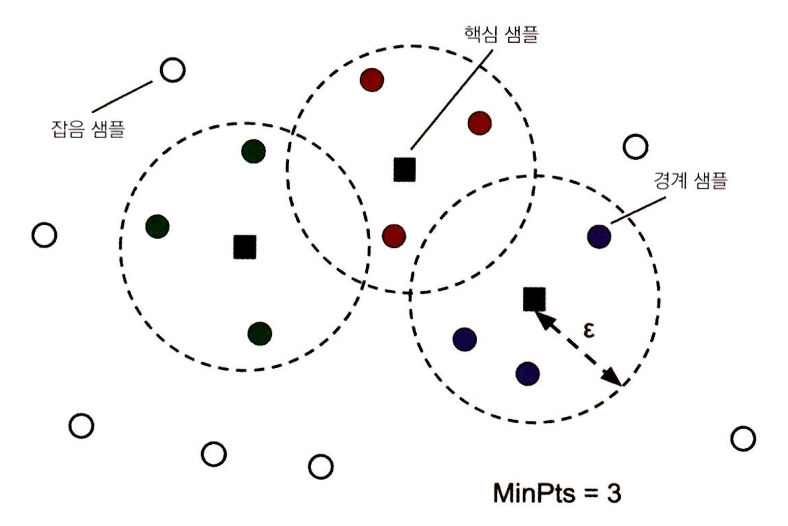  
2. **클러스터 생성**: 개별 핵심 샘플 또는 ε 이내에 있는 핵심 샘플을 연결한 그룹을 클러스터로 생성
3. **경계 샘플 할당**: 경계 샘플을 해당 핵심 샘플의 클러스터에 할당
### [장단점]
- 장점
    - k-means와 달리 임의의 기하학적 분포를 갖는 데이터도 처리 가능(밀도에 따라 클러스터를 할당하기 때문)
    - 이상치에 민감하지 X
    - 잡음 샘플 구분 -> 모든 샘플을 클러스터에 할당하지 X
- 단점
    - epsilon, min_samples 설정에 영향 많이 받음
    - epsilon 조절 어려움
    - 연산량 많아서 속도 느림
    - 다른 밀도 분포를 가진 데이터의 군집 분석 어려움 <- 단일 밀도 기준의 한계
    - 밀도가 낮은 곳의 데이터는 노이즈로 구분할 가능성
    - 변수가 낮을수록 정확도 떨어짐
### [HDBSCAN]
DBSCAN을 계층적 군집화처럼 변환한 버전
- 작동방식: 밀도 기반 1차 군집화 -> 거리 기준으로 밀도 기반 군집 반복 연결
- 주요 파라미터: min_cluster_size(클러스터 인정을 위한 최소 샘플 수), min_samples
- 장점: 여러 밀도 기준으로 반복 수행 -> 단일 밀도 기준 한계 보완

## Gaussian Mixture Model(GMM)
- 정의: **데이터가 여러 다른 모양의 가우시안 분포(정규분포)로 구성되었다고 가정**하고, **각 분포를 클러스터로 인식**하는 군집화 방법
- **모델 기반 군집화**: 데이터를 생성하는 통계적 모델을 가정하고, 데이터가 해당 모델로부터 생성되었다는 전제 하에 군집화 수행
- 전체 데이터 분포를 여러 확률 분포의 혼합으로 모델링하고, 각 군집을 확률 분포로 간주
### [가정]
- 관측된 데이터: 특정 가우시안 확률 분포에 의해 생성
- 전체 데이터셋: 여러 개의 다변량 가우시안 분포 혼합
- 개별 데이터: 우도에 따라 K개의 가우시안 분포 중 하나에 속함
### [진행 과정]
1. 주어진 전체 데이터셋의 분포 확인
2. 전체 데이터셋이 서로 다른 정규분포 형태의 확률분포 곡선으로 구성돼있다고 가정
3. 전체 데이터셋을 구성하는 여러 개의 정규분포 곡선 추출(->하나의 군집), 개별 데이터가 이 중 어떤 정규분포에 속하는지 결정
### [파라미터 추정]
- **기댓값-최대화(EM) 알고리즘** 사용
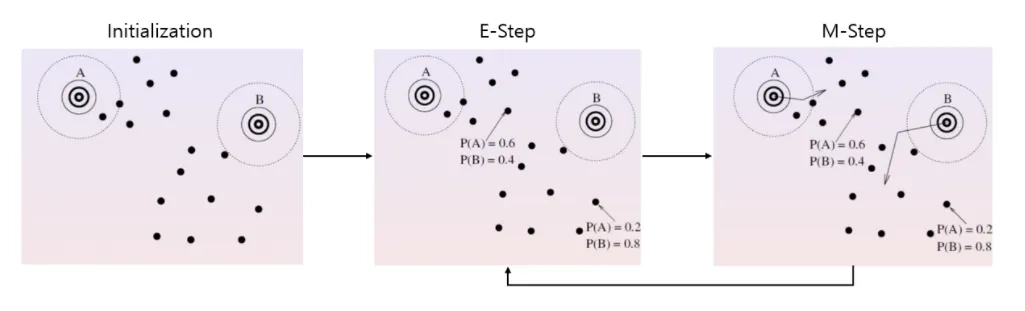  
    1. **Initialization** : 필요한 파라미터 $u, \Sigma, \pi$에 대해 초기값 선정
    2. **E(Expectation) step** : 현재 $\theta$를 통해 $x$가 특정 분포(군집)에 속할 사후확률을 계산
    3. **M(Maximization) step** : 계산된 사후확률을 통해 $u, \Sigma, \pi$를 다시 추정
    4. 수렴 조건이 만족될 때까지 반복 E step, M step을 반복
### [장단점]
- 장점: k-means보다 유연
- 단점: 수행시간 오래 걸림, 가우시안 분포에 맞지 않을 경우 복잡도 상승, 성능 저하

# **군집화 평가 방법**
## 외부 평가와 내부 평가
- 외부 평가: **정답 레이블이 존재한는 경우** 사용. 군집화 결과와 실제 정답을 비교해 유사도 평가
    - ARI(Adjusted Rand Index): 조정된 랜드 지수. 군집화 결과와 실제 레이블 간의 일치도(-1~1) 측정
    *랜드지수를 보완해 우연에 의한 일치 가능성을 배제한 것*
- 내부 평가: **정답 레이블이 없는 경우** 사용. 군집 내부 응집도와 군집 간 분리도를 기반으로 군집 품질 정량적 측정
    - K-means: SSE(제곱오차합) 최소화
    - GMM: 로그 우도(모델이 주어진 데이터를 얼마나 잘 설명하는지 나타내는 지표) 최대화
## 실루엣 계수
- 정의: 클러스터 내 샘플들이 얼마나 조밀하게 모여있는지 측정하는 도구 -> 군집 품질 확인 $$ s^{(i)} = \frac{b^{(i)} - a^{(i)}}{\max \left\{ b^{(i)}, a^{(i)} \right\}} $$
### [계산]
1. 샘플 $\mathbf{x}^{(i)}$와 동일한 클러스터 내 모든 다른 포인트 사이의 거리를 평균하여 클러스터 응집력 $\mathbf{a}^{(i)}$ 계산
2. 샘플 $\mathbf{x}^{(i)}$와 가장 가까운 클러스터의 모든 샘플 간 평균 거리로 최근접 클러스터의 클러스터 분리도 $\mathbf{b}^{(i)}$ 계산
3. 클러스터 분리도에서 응집도를 뺀 값을 둘 중 큰 값으로 나누어 실루엣 $s^{(i)}$ 계산
### [해석]
| 조건 | 실루엣 계수 값 | 의미 | 평가 |
| --- | --- | --- | --- |
| **분리도 > 응집도** | 1에 가까움 | 샘플이 자신의 클러스터에 잘 속해 있고, 다른 클러스터와는 멀리 떨어져 있음 | **군집화가 잘 됨** |
| **분리도 = 응집도** | 0에 가까움 | 샘플이 클러스터의 경계에 위치하여 군집 간 거리가 모호 | 군집 간 분리가 명확하지 않음 |
| **분리도 < 응집도** | -1에 가까움 | 샘플이 잘못된 클러스터에 할당되어 군집이 섞여 있는 상태 | **군집화가 잘못됨** |
### [시각화]
- 빨간 점선 = 모든 군집의 평균 실루엣 계수. **0.7이상이면 군집화가 잘 된 것**
- **각 군집의 실루엣 계수 값 분포가 고를수록** 군집화가 잘 된 것
- 군집화가 잘 된 경우 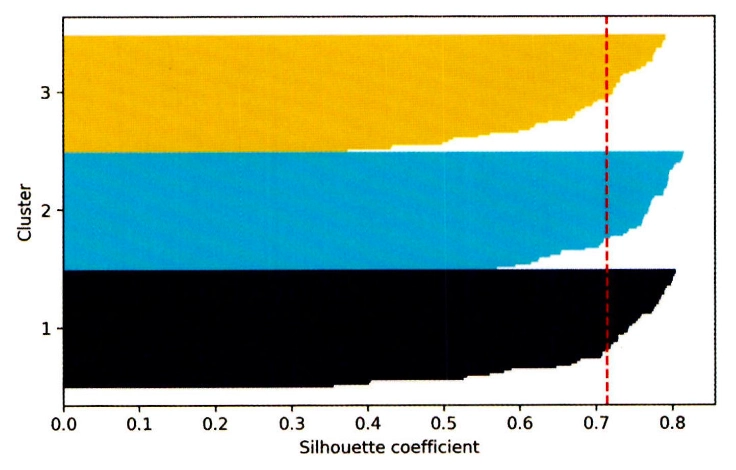  
- 군집화가 잘 되지 않은 경우 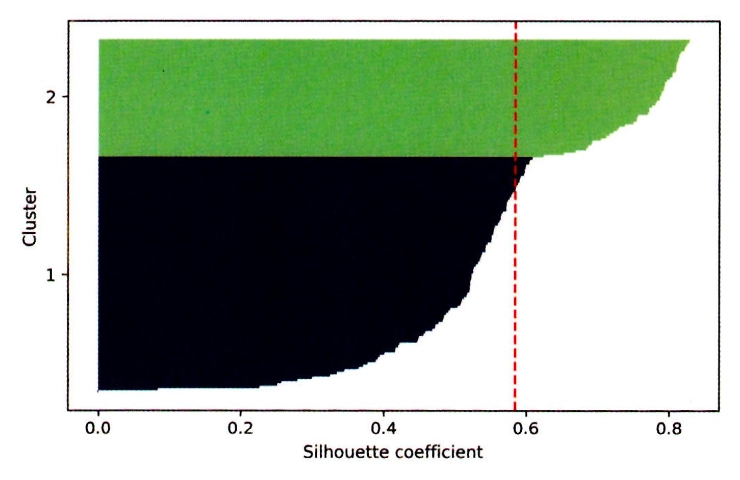

## Dunn Index
- 정의:  **클러스터 간 최소 거리**(분리도)와 **클러스터 내 최대 거리**(응집도)의 비율을 계산해 클러스터링의 품질을 평가하는 지표 $$ \text{Dunn Index} = \frac{
\min\limits_{i \ne j} \; d(C_i, C_j)}{\max\limits_{1 \le k \le K} \; \delta(C_k)} $$  
( $d(C_i, C_j)$ : 클러스터 $C_i$와 $C_j$ 사이의 거리(분리도), $\delta(C_k)$ : 클러스터 $C_k$ 내의 최대 거리(응집도))
### [해석]
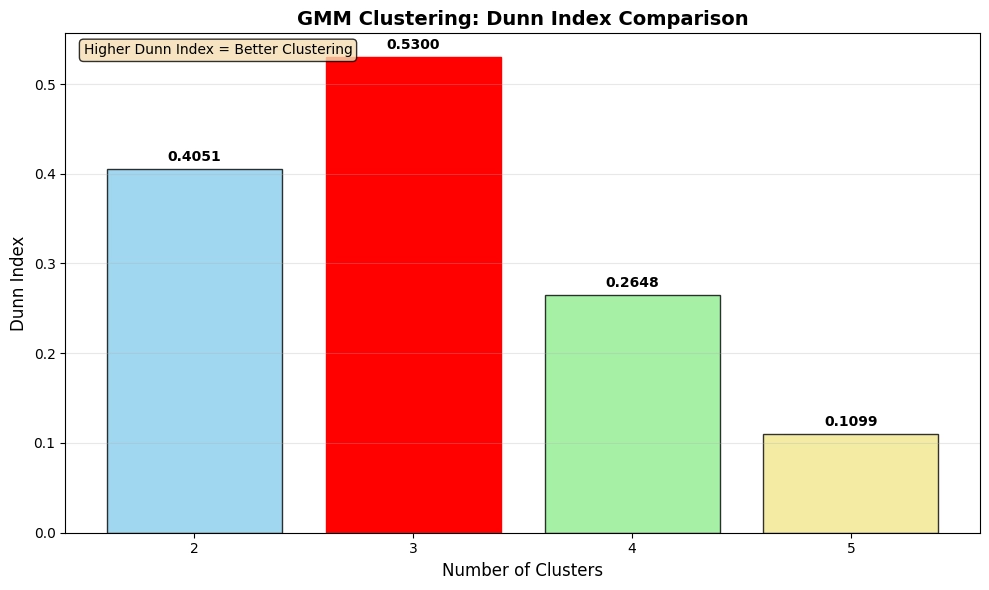  
- Dunn Index 값이 클수록 군집화가 잘 된 것 <- 분리도가 높고 응집도가 작은 것
- 0부터 무한대까지 가능
- 실루엣 계수와 종합적으로 평가하기
### [한계]
- 군집 수에 비례하여 계산 비용 증가
- 가장 멀거나 가까운 포인트, 군집 등에 큰 영향을 받음
- 이상치에 민감 -> 수치가 급격히 감소 가능